# 06 — Domain Adaptation: DANN (E6)

DANN (Ganin & Lempitsky, 2015) adversarial domain alignment pipeline:
1. Mixed batches: source (ISIC 2018) + target (ISIC 2020) with domain labels
2. Shared backbone extracts features; task head classifies melanoma (source only)
3. Domain classifier with Gradient Reversal Layer predicts source vs target
4. GRL inverts gradient → backbone learns domain-invariant features
5. Lambda schedule: Ganin progressive λ(p) = 2/(1+exp(-10p))-1

**Perché DANN?** E4 (pseudo-label) fallisce per confidence bias sotto domain shift.
E5 (Mean Teacher) fallisce perché consistency loss su target inaffidabile.
DANN attacca il domain shift alla radice: allinea le distribuzioni a livello di feature
invece di operare nello spazio delle predizioni.

Evaluate on source test (ISIC 2018) + target test (ISIC 2020).
Compare AUC vs Label Budget against E2 baseline, E3 SSL, E4 pseudo-label, E5 Mean Teacher.

**Flag di controllo:**
- `RUN_DANN` — True per forzare ri-training anche se run gia completo
- `RUN_EVAL` — True per forzare ricalcolo test_metrics

In [1]:
import os, sys, copy, json, torch, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import (
    evaluate_and_report, evaluate_on_csv, get_latest_run,
    collect_predictions, plot_training_history, collect_auc_vs_fraction, NumpyEncoder,
)
from src.trainers.dann import run_dann
from src.trainers.supervised import run_experiment
from src.utils import get_device, load_config, init_run_dir, cleanup
from src.metrics import compute_metrics, plot_auc_vs_labels, plot_confusion_matrix, plot_roc_curve, plot_tsne
from data.scripts.make_label_subsets import FRACTIONS

ALL_FRACTIONS = FRACTIONS + [1.0]
print('ALL_FRACTIONS:', ALL_FRACTIONS)

ALL_FRACTIONS: [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [2]:
config = load_config('configs/dann.yaml')
config

{'experiment': {'name': 'dann_resnet18', 'seed': 42, 'device': 'auto'},
 'data': {'task': 'dann',
  'source_csv': 'data/processed/isic2018/train.csv',
  'target_csv': 'data/processed/isic2020/train.csv',
  'val_csv': 'data/processed/isic2018/val.csv',
  'img_size': 224,
  'batch_size': 64,
  'num_workers': 0,
  'include_target_labels': False,
  'label_col': 'target',
  'max_target_samples': 4000,
  'balanced_domains': True},
 'model': {'arch': 'resnet18', 'pretrained': True, 'num_classes': 1},
 'training': {'epochs': 50,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'lr_domain': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs': 0},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'da': {'lambda_schedule': 'dann', 'lambda_max': 0.3, 'use_coral': False},
 'early_stopping': {'patience': 10, 'monitor': 'val_auc'},
 'logging': {'save_dir': 'results/runs'}}

## 1. DANN training loop

Per ogni frazione:
1. Configura source CSV = subset ISIC 2018 (o full se frazione=1.0)
2. Lancia `run_dann` su mixed batches (source ISIC 2018 + target ISIC 2020)
3. Salva run in `results/runs/dann_ft_{fraction}/`

Skip se run finale + checkpoints/best.pt esistono e `RUN_DANN=False`.
Usa `copy.deepcopy(config)` per evitare mutazione tra iterazioni.

**Balanced domain sampler:** Quando `balanced_domains=true` nel config, `build_loaders` usa un `WeightedRandomSampler`
con pesi inversamente proporzionali alla numerosità di ciascun dominio. Ogni batch contiene ~50% source + ~50% target,
garantendo che il domain classifier non possa discriminare per proporzione. Fondamentale per il GRL adversarial game,
specialmente a basse frazioni dove source sarebbe altrimenti sottorappresentato (1 source + 63 target per batch).

**Focal Loss** gestisce l'imbalance di classe sul source. λ_max ridotto a 0.3 per GRL più gentile.

In [3]:
RUN_DANN = True  # True per forzare ri-training

device = get_device(config['experiment'].get('device', 'auto'))
print(f'Device: {device}')

for fraction in ALL_FRACTIONS:
    exp_name = f'dann_ft_{fraction:.2f}'
    run_dir_ft = get_latest_run(exp_name)
    ft_complete = run_dir_ft is not None and (run_dir_ft / 'checkpoints/best.pt').exists()

    if ft_complete and not RUN_DANN:
        print(f'[SKIP] {exp_name} — run gia completa')
        cleanup()
        continue

    # Build config for this fraction
    dann_cfg = copy.deepcopy(config)
    if fraction >= 1.0:
        dann_cfg['data']['source_csv'] = 'data/processed/isic2018/train.csv'
    else:
        pct = int(round(fraction * 100))
        dann_cfg['data']['source_csv'] = f'data/processed/isic2018/subsets/train_{pct:02d}pct.csv'
    dann_cfg['data']['target_csv'] = 'data/processed/isic2020/train.csv'
    dann_cfg['data']['val_csv'] = 'data/processed/isic2018/val.csv'
    dann_cfg['experiment']['name'] = exp_name

    print(f"\n{'='*55}")
    print(f'DANN | fraction={fraction:.2f}')
    print(f"{'='*55}")

    result = run_dann(dann_cfg)
    print(f'[OK] {exp_name} | best_val_auc={result["best_val_auc"]:.4f}')

    # Free memory before next fraction
    del result, dann_cfg
    cleanup()

print('\nDANN training loop completato.')

Device: mps

DANN | fraction=0.01


[2026-06-05 00:42:47,150] INFO - {'epoch': 1, 'train_loss': 0.042065518159492346, 'train_cls_loss': 0.025076792775518664, 'train_dom_loss': 0.5661719331554338, 'lambda': 0.02990039838748677, 'val_loss': 0.05064867787457608, 'val_auc': 0.7547221378682052, 'val_balanced_accuracy': 0.6239902824172487, 'val_macro_f1': 0.6145661157024793, 'val_monitor': 0.7547221378682052}
[2026-06-05 00:44:17,245] INFO - {'epoch': 2, 'train_loss': 0.04601952201303314, 'train_cls_loss': 0.008697589529668016, 'train_dom_loss': 0.631087089286131, 'lambda': 0.0592125960674712, 'val_loss': 0.06591859938470752, 'val_auc': 0.7619597125215103, 'val_balanced_accuracy': 0.639219556635287, 'val_macro_f1': 0.6156416983248852, 'val_monitor': 0.7619597125215103}
[2026-06-05 00:45:45,682] INFO - {'epoch': 3, 'train_loss': 0.05946342612014097, 'train_cls_loss': 0.0038789569204505324, 'train_dom_loss': 0.636360186922784, 'lambda': 0.08739378373547724, 'val_loss': 0.10478490191352713, 'val_auc': 0.6599959510071871, 'val_bal

[OK] dann_ft_0.01 | best_val_auc=0.7620

DANN | fraction=0.05


[2026-06-05 01:00:12,811] INFO - {'epoch': 1, 'train_loss': 0.050670036199417984, 'train_cls_loss': 0.03474190442179766, 'train_dom_loss': 0.5432699836384166, 'lambda': 0.02990039838748677, 'val_loss': 0.036512033833371295, 'val_auc': 0.7857171778520093, 'val_balanced_accuracy': 0.6296285049094038, 'val_macro_f1': 0.6160547945205479, 'val_monitor': 0.7857171778520093}
[2026-06-05 01:01:48,043] INFO - {'epoch': 2, 'train_loss': 0.06653951940211383, 'train_cls_loss': 0.028513700748716883, 'train_dom_loss': 0.642338220206174, 'lambda': 0.0592125960674712, 'val_loss': 0.03536596688275392, 'val_auc': 0.8092013361676282, 'val_balanced_accuracy': 0.6809241826095759, 'val_macro_f1': 0.6279092702169625, 'val_monitor': 0.8092013361676282}
[2026-06-05 01:03:22,326] INFO - {'epoch': 3, 'train_loss': 0.08230256660418077, 'train_cls_loss': 0.025214913934503574, 'train_dom_loss': 0.65273634520444, 'lambda': 0.08739378373547724, 'val_loss': 0.03621801381352005, 'val_auc': 0.821611499139589, 'val_balan

[OK] dann_ft_0.05 | best_val_auc=0.8216

DANN | fraction=0.10


...

[OK] dann_ft_0.25 | best_val_auc=0.8747

DANN | fraction=0.50


[2026-06-05 02:34:23,135] INFO - {'epoch': 1, 'train_loss': 0.055355777099910984, 'train_cls_loss': 0.03822113489256288, 'train_dom_loss': 0.5736532322234164, 'lambda': 0.02990039838748677, 'val_loss': 0.03570150541370506, 'val_auc': 0.8236461180281405, 'val_balanced_accuracy': 0.6825893309039377, 'val_macro_f1': 0.640131271075977, 'val_monitor': 0.8236461180281405}
[2026-06-05 02:37:02,929] INFO - {'epoch': 2, 'train_loss': 0.07159530715665578, 'train_cls_loss': 0.03384546452997475, 'train_dom_loss': 0.6388891295674382, 'lambda': 0.0592125960674712, 'val_loss': 0.0340536166127626, 'val_auc': 0.8290110335054156, 'val_balanced_accuracy': 0.6695971252151027, 'val_macro_f1': 0.6515298031176266, 'val_monitor': 0.8290110335054156}
[2026-06-05 02:39:39,390] INFO - {'epoch': 3, 'train_loss': 0.08819263666875655, 'train_cls_loss': 0.03302366739924447, 'train_dom_loss': 0.6298438986926683, 'lambda': 0.08739378373547724, 'val_loss': 0.034529692369636954, 'val_auc': 0.828201234942808, 'val_balanc

[OK] dann_ft_0.50 | best_val_auc=0.9047

DANN | fraction=1.00


[2026-06-05 03:56:51,036] INFO - {'epoch': 1, 'train_loss': 0.05310504180275318, 'train_cls_loss': 0.03584110111696058, 'train_dom_loss': 0.5786941908535622, 'lambda': 0.02990039838748677, 'val_loss': 0.0346119222617322, 'val_auc': 0.8265613928535277, 'val_balanced_accuracy': 0.7096163579309647, 'val_macro_f1': 0.6580210709242967, 'val_monitor': 0.8265613928535277}
[2026-06-05 04:00:41,423] INFO - {'epoch': 2, 'train_loss': 0.07103577206829886, 'train_cls_loss': 0.033297079373695956, 'train_dom_loss': 0.6365343144326618, 'lambda': 0.0592125960674712, 'val_loss': 0.03165084352860084, 'val_auc': 0.8662212774572325, 'val_balanced_accuracy': 0.6920589128454298, 'val_macro_f1': 0.7081793179317932, 'val_monitor': 0.8662212774572325}
[2026-06-05 04:04:30,497] INFO - {'epoch': 3, 'train_loss': 0.09021404526242009, 'train_cls_loss': 0.03313792041093837, 'train_dom_loss': 0.6521138293005568, 'lambda': 0.08739378373547724, 'val_loss': 0.030968685747011677, 'val_auc': 0.874592570098188, 'val_balan

[OK] dann_ft_1.00 | best_val_auc=0.9234

DANN training loop completato.


## 2. Valutazione su source (ISIC 2018) e target (ISIC 2020)

Carica `best.pt` da ogni run DANN, valuta su entrambi test set.
Il checkpoint salvato ha chiave `"model"` compatibile con `evaluate_on_csv`.
Salva `test_metrics.json` (source) e `test_metrics_isic2020.json` (target).
Salta se file esistono gia e `RUN_EVAL=False`.

In [4]:
RUN_EVAL = False

device = get_device(config['experiment'].get('device', 'auto'))

for fraction in ALL_FRACTIONS:
    exp_name = f'dann_ft_{fraction:.2f}'
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        print(f'[SKIP] {exp_name}: run non trovato')
        cleanup()
        continue
    ckpt_path = run_dir / 'checkpoints/best.pt'
    if not ckpt_path.exists():
        print(f'[SKIP] {exp_name}: best.pt mancante')
        cleanup()
        continue

    src_metrics_path = run_dir / 'test_metrics.json'
    tgt_metrics_path = run_dir / 'test_metrics_isic2020.json'
    both_exist = src_metrics_path.exists() and tgt_metrics_path.exists()
    if both_exist and not RUN_EVAL:
        src_auc = json.load(open(src_metrics_path)).get('auc_roc', '?')
        tgt_auc = json.load(open(tgt_metrics_path)).get('auc_roc', '?')
        print(f'[SKIP] {exp_name}: src={src_auc:.4f} tgt={tgt_auc:.4f} (cached)')
        cleanup()
        continue

    # Evaluate source
    src_auc = evaluate_on_csv(
        run_dir, config,
        test_csv='data/processed/isic2018/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics.json',
    )
    src_val = src_auc.get('auc_roc') if src_auc else None

    # Evaluate target
    tgt_auc = evaluate_on_csv(
        run_dir, config,
        test_csv='data/processed/isic2020/test.csv',
        train_csv='data/processed/isic2018/train.csv',
        batch_size=64, device=device,
        metrics_name='test_metrics_isic2020.json',
    )
    tgt_val = tgt_auc.get('auc_roc') if tgt_auc else None

    print(f'[DONE] {exp_name}: src={src_val:.4f} tgt={tgt_val:.4f}')
    cleanup()

print('\nValutazione completata.')

[DONE] dann_ft_0.01: src=0.7929 tgt=0.6233
[DONE] dann_ft_0.05: src=0.8373 tgt=0.7076
[DONE] dann_ft_0.10: src=0.8576 tgt=0.7031
[DONE] dann_ft_0.25: src=0.8799 tgt=0.5192
[DONE] dann_ft_0.50: src=0.8838 tgt=0.6204
[DONE] dann_ft_1.00: src=0.9179 tgt=0.5888

Valutazione completata.


## 3. Raccolta AUC — Baseline, SSL, Pseudo-label, Mean Teacher, DANN

In [5]:
def _read_auc(run_dir, filename):
    p = run_dir / filename
    if p.exists():
        return json.load(open(p)).get('auc_roc')
    return None

# ── DANN (from E6 runs) ─────────────────────────────────────────────────
aucs_2018_dann, aucs_2020_dann = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'dann_ft_{f:.2f}')
    aucs_2018_dann[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_dann[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Mean Teacher (from E5 runs) ─────────────────────────────────────────
aucs_2018_mt, aucs_2020_mt = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'mean_teacher_ft_{f:.2f}')
    aucs_2018_mt[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_mt[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Pseudo-label (from E4 runs) ─────────────────────────────────────────
aucs_2018_pseudo, aucs_2020_pseudo = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'pseudo_label_ft_{f:.2f}')
    aucs_2018_pseudo[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_pseudo[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Baseline (from E2 runs) ──────────────────────────────────────────────
aucs_2018_base, aucs_2020_base = {}, {}
for f in FRACTIONS:
    rd = get_latest_run(f'baseline_resnet18_{f:.2f}')
    aucs_2018_base[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_base[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None
rd_full = get_latest_run('baseline_resnet18_full')
aucs_2018_base[1.0] = _read_auc(rd_full, 'test_metrics.json') if rd_full else None
aucs_2020_base[1.0] = _read_auc(rd_full, 'test_metrics_isic2020.json') if rd_full else None

# ── SSL (from E3 runs) ───────────────────────────────────────────────────
aucs_2018_ssl, aucs_2020_ssl = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(f'simclr_ft_{f:.2f}')
    aucs_2018_ssl[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_ssl[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

print('DANN  source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_dann.items() if v})
print('DANN  target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_dann.items() if v})
print('MT     source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_mt.items() if v})
print('MT     target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_mt.items() if v})
print('Pseudo source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_pseudo.items() if v})
print('Pseudo target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_pseudo.items() if v})
print('Base  source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_base.items() if v})
print('Base  target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_base.items() if v})
print('SSL   source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_ssl.items() if v})
print('SSL   target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_ssl.items() if v})

DANN  source: {'1%': 0.7929, '5%': 0.8373, '10%': 0.8576, '25%': 0.8799, '50%': 0.8838, '100%': 0.9179}
DANN  target: {'1%': 0.6233, '5%': 0.7076, '10%': 0.7031, '25%': 0.5192, '50%': 0.6204, '100%': 0.5888}
MT     source: {'1%': 0.74, '5%': 0.858, '10%': 0.856, '25%': 0.8873, '50%': 0.9012, '100%': 0.9077}
MT     target: {'1%': 0.5521, '5%': 0.6839, '10%': 0.6893, '25%': 0.6699, '50%': 0.6947, '100%': 0.6918}
Pseudo source: {'10%': 0.866, '25%': 0.8711, '50%': 0.9063, '100%': 0.9244}
Pseudo target: {'10%': 0.6725, '25%': 0.6255, '50%': 0.6445, '100%': 0.6473}
Base  source: {'1%': 0.8138, '5%': 0.8629, '10%': 0.8631, '25%': 0.8679, '50%': 0.9065, '100%': 0.9181}
Base  target: {'1%': 0.6619, '5%': 0.7118, '10%': 0.6853, '25%': 0.6294, '50%': 0.6353, '100%': 0.6975}
SSL   source: {'1%': 0.8451, '5%': 0.873, '10%': 0.8699, '25%': 0.8836, '50%': 0.909, '100%': 0.934}
SSL   target: {'1%': 0.7984, '5%': 0.6736, '10%': 0.6559, '25%': 0.6144, '50%': 0.6817, '100%': 0.6939}


## 4. Plot AUC vs Label Budget — 10-line comparison (all methods)

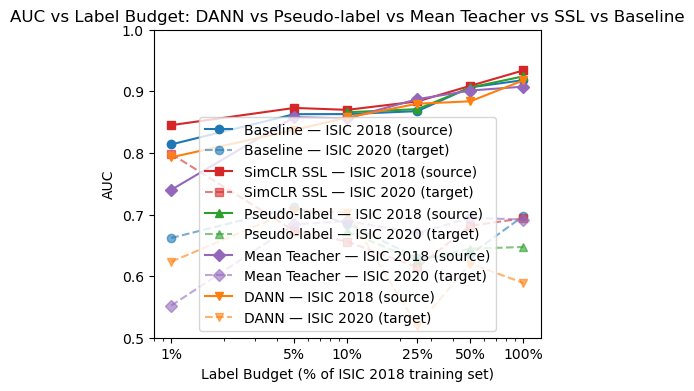

Figura salvata in results/figures/auc_vs_labels_dann.png


In [6]:
results = {
    'Baseline — ISIC 2018 (source)':         {f: v for f, v in aucs_2018_base.items() if v is not None},
    'Baseline — ISIC 2020 (target)':         {f: v for f, v in aucs_2020_base.items() if v is not None},
    'SimCLR SSL — ISIC 2018 (source)':       {f: v for f, v in aucs_2018_ssl.items() if v is not None},
    'SimCLR SSL — ISIC 2020 (target)':       {f: v for f, v in aucs_2020_ssl.items() if v is not None},
    'Pseudo-label — ISIC 2018 (source)':     {f: v for f, v in aucs_2018_pseudo.items() if v is not None},
    'Pseudo-label — ISIC 2020 (target)':     {f: v for f, v in aucs_2020_pseudo.items() if v is not None},
    'Mean Teacher — ISIC 2018 (source)':     {f: v for f, v in aucs_2018_mt.items() if v is not None},
    'Mean Teacher — ISIC 2020 (target)':     {f: v for f, v in aucs_2020_mt.items() if v is not None},
    'DANN — ISIC 2018 (source)':             {f: v for f, v in aucs_2018_dann.items() if v is not None},
    'DANN — ISIC 2020 (target)':             {f: v for f, v in aucs_2020_dann.items() if v is not None},
}
style_map = {
    'Baseline — ISIC 2018 (source)':         {'color': 'tab:blue',   'linestyle': '-',  'marker': 'o'},
    'Baseline — ISIC 2020 (target)':         {'color': 'tab:blue',   'linestyle': '--', 'marker': 'o', 'alpha': 0.6},
    'SimCLR SSL — ISIC 2018 (source)':       {'color': 'tab:red',    'linestyle': '-',  'marker': 's'},
    'SimCLR SSL — ISIC 2020 (target)':       {'color': 'tab:red',    'linestyle': '--', 'marker': 's', 'alpha': 0.6},
    'Pseudo-label — ISIC 2018 (source)':     {'color': 'tab:green',  'linestyle': '-',  'marker': '^'},
    'Pseudo-label — ISIC 2020 (target)':     {'color': 'tab:green',  'linestyle': '--', 'marker': '^', 'alpha': 0.6},
    'Mean Teacher — ISIC 2018 (source)':     {'color': 'tab:purple', 'linestyle': '-',  'marker': 'D'},
    'Mean Teacher — ISIC 2020 (target)':     {'color': 'tab:purple', 'linestyle': '--', 'marker': 'D', 'alpha': 0.6},
    'DANN — ISIC 2018 (source)':             {'color': 'tab:orange', 'linestyle': '-',  'marker': 'v'},
    'DANN — ISIC 2020 (target)':             {'color': 'tab:orange', 'linestyle': '--', 'marker': 'v', 'alpha': 0.6},
}
out_path = 'results/figures/auc_vs_labels_dann.png'
fig = plot_auc_vs_labels(
    results,
    save_path=out_path,
    x_scale='log',
    x_as_percent=True,
    title='AUC vs Label Budget: DANN vs Pseudo-label vs Mean Teacher vs SSL vs Baseline',
    ylim=(0.5, 1.0),
    style_map=style_map,
)
plt.show()
print(f'Figura salvata in {out_path}')

## 5. Summary table

In [7]:
def _s(d, f):
    v = d.get(f)
    return round(v, 4) if v is not None else float('nan')

rows = []
for f in ALL_FRACTIONS:
    rows.append({
        'fraction':             f'{f*100:.0f}%',
        'base_src_auc':         _s(aucs_2018_base, f),
        'base_tgt_auc':         _s(aucs_2020_base, f),
        'ssl_src_auc':          _s(aucs_2018_ssl, f),
        'ssl_tgt_auc':          _s(aucs_2020_ssl, f),
        'pseudo_src_auc':       _s(aucs_2018_pseudo, f),
        'pseudo_tgt_auc':       _s(aucs_2020_pseudo, f),
        'mt_src_auc':           _s(aucs_2018_mt, f),
        'mt_tgt_auc':           _s(aucs_2020_mt, f),
        'dann_src_auc':         _s(aucs_2018_dann, f),
        'dann_tgt_auc':         _s(aucs_2020_dann, f),
        'delta_dann_vs_base_src': round(_s(aucs_2018_dann, f) - _s(aucs_2018_base, f), 4),
        'delta_dann_vs_base_tgt': round(_s(aucs_2020_dann, f) - _s(aucs_2020_base, f), 4),
        'delta_dann_vs_mt_tgt':   round(_s(aucs_2020_dann, f) - _s(aucs_2020_mt, f), 4),
        'delta_dann_vs_ssl_tgt':  round(_s(aucs_2020_dann, f) - _s(aucs_2020_ssl, f), 4),
    })

df = pd.DataFrame(rows).set_index('fraction')
print(df.to_string())
Path('results/metrics').mkdir(parents=True, exist_ok=True)
df.to_csv('results/metrics/dann_vs_baseline.csv')
print('\nSalvato in results/metrics/dann_vs_baseline.csv')

          base_src_auc  base_tgt_auc  ssl_src_auc  ssl_tgt_auc  pseudo_src_auc  pseudo_tgt_auc  mt_src_auc  mt_tgt_auc  dann_src_auc  dann_tgt_auc  delta_dann_vs_base_src  delta_dann_vs_base_tgt  delta_dann_vs_mt_tgt  delta_dann_vs_ssl_tgt
fraction                                                                                                                                                                                                                                       
1%              0.8138        0.6619       0.8451       0.7984             NaN             NaN      0.7400      0.5521        0.7929        0.6233                 -0.0209                 -0.0386                0.0712                -0.1751
5%              0.8629        0.7118       0.8730       0.6736             NaN             NaN      0.8580      0.6839        0.8373        0.7076                 -0.0256                 -0.0042                0.0237                 0.0340
10%             0.8631        0.6853    

## 6. t-SNE visualization — domain alignment before vs after DANN

Estrae feature dal backbone (layer pre-classificatore) su subset di ISIC 2018 e ISIC 2020.
Mostra due plot: (1) feature pre-addestrate (baseline ImageNet) e (2) feature dopo DANN.
Se i domini si sovrappongono nel plot post-DANN → l'allineamento funziona.

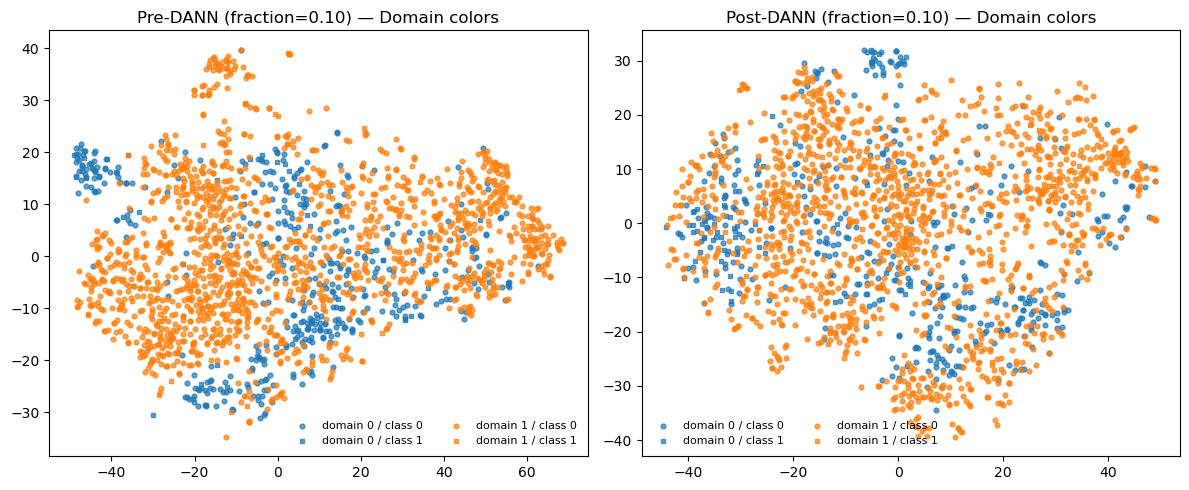

t-SNE salvato in results/runs/dann_ft_0.10/20260605_011914/figures/tsne_dann.png


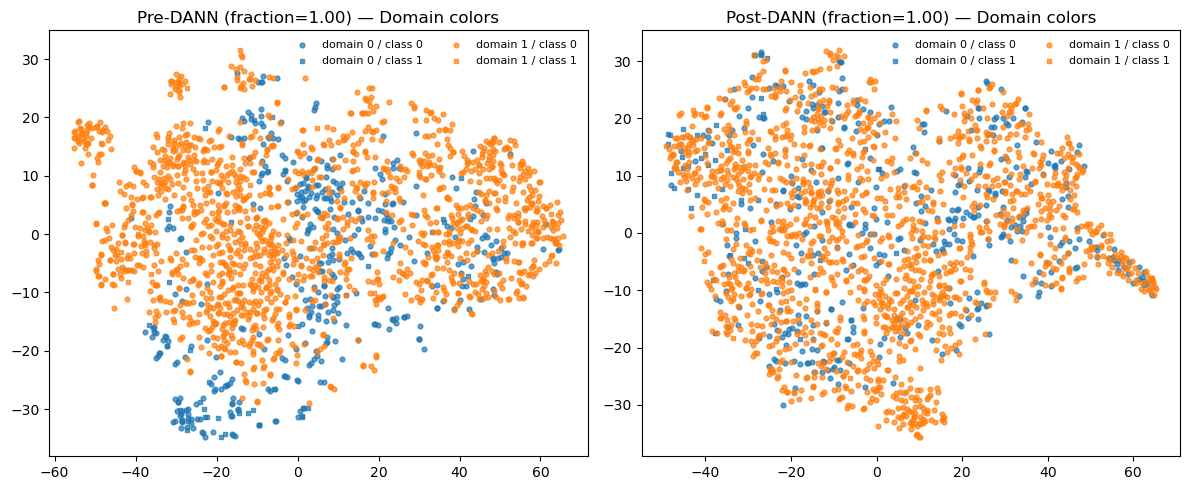

t-SNE salvato in results/runs/dann_ft_1.00/20260605_035302/figures/tsne_dann.png

t-SNE visualization completata.


In [8]:
def extract_features(backbone, loader, device, max_samples=2000):
    """Extract features from backbone for t-SNE visualization."""
    backbone.eval()
    all_feats = []
    all_domains = []
    all_labels = []
    n_collected = 0
    with torch.no_grad():
        for images, class_labels, domain_labels in loader:
            if n_collected >= max_samples:
                break
            images = images.to(device)
            feats = backbone(images).detach().cpu().numpy()
            all_feats.append(feats)
            all_domains.append(domain_labels.numpy())
            all_labels.append(class_labels.numpy())
            n_collected += len(images)
    return (
        np.concatenate(all_feats)[:max_samples],
        np.concatenate(all_domains)[:max_samples],
        np.concatenate(all_labels)[:max_samples],
    )

# Build a mixed source+target loader for feature extraction (val transforms)
from src.augmentations import get_val_transforms
from src.datasets import DomainDataset

viz_ds = DomainDataset(
    source_csv='data/processed/isic2018/train.csv',
    target_csv='data/processed/isic2020/train.csv',
    transforms=get_val_transforms(224),
    include_target_labels=True,  # keep target labels for reference
)
# Shuffle=True per mescolare source+target — altrimenti prime N righe sono solo source
viz_loader = torch.utils.data.DataLoader(
    viz_ds, batch_size=64, shuffle=True, num_workers=2
)

device = get_device(config['experiment'].get('device', 'auto'))

for fraction in [0.10, 1.00]:  # due frazioni rappresentative
    exp_name = f'dann_ft_{fraction:.2f}'
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        print(f'[SKIP] {exp_name}: run non trovato')
        continue
    ckpt_path = run_dir / 'checkpoints/best.pt'
    if not ckpt_path.exists():
        print(f'[SKIP] {exp_name}: best.pt mancante')
        continue

    ckpt = torch.load(ckpt_path, map_location=device)

    # ── Pre-DANN: pretrained backbone (no DANN) ────────────────────────
    model_pre = build_backbone(
        arch=config['model']['arch'],
        pretrained=True,
        num_classes=0,  # features only
    ).to(device)
    feats_pre, domains_pre, labels_pre = extract_features(model_pre, viz_loader, device, max_samples=2000)

    # ── Post-DANN: trained backbone ────────────────────────────────────
    from src.models import build_dann_model
    dann_models = build_dann_model(
        backbone_arch=config['model']['arch'],
        num_classes=config['model'].get('num_classes', 1),
        pretrained=False,
    )
    model_post = dann_models['backbone'].to(device)
    # Load only backbone weights (not task_head or domain_classifier)
    missing, unexpected = model_post.load_state_dict(ckpt['backbone'])
    feats_post, domains_post, labels_post = extract_features(model_post, viz_loader, device, max_samples=2000)

    # ── t-SNE side-by-side ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pre-DANN: colored by domain
    plot_tsne(feats_pre, labels_pre, domain_labels=domains_pre, ax=axes[0])
    axes[0].set_title(f'Pre-DANN (fraction={fraction:.2f}) — Domain colors')

    # Post-DANN: colored by domain
    plot_tsne(feats_post, labels_post, domain_labels=domains_post, ax=axes[1])
    axes[1].set_title(f'Post-DANN (fraction={fraction:.2f}) — Domain colors')

    save_path = run_dir / 'figures/tsne_dann.png'
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f't-SNE salvato in {save_path}')

    # Free memory
    del model_pre, model_post, ckpt, feats_pre, feats_post
    cleanup()

print('\nt-SNE visualization completata.')

## 7. Diagnostica — training history e metriche di training

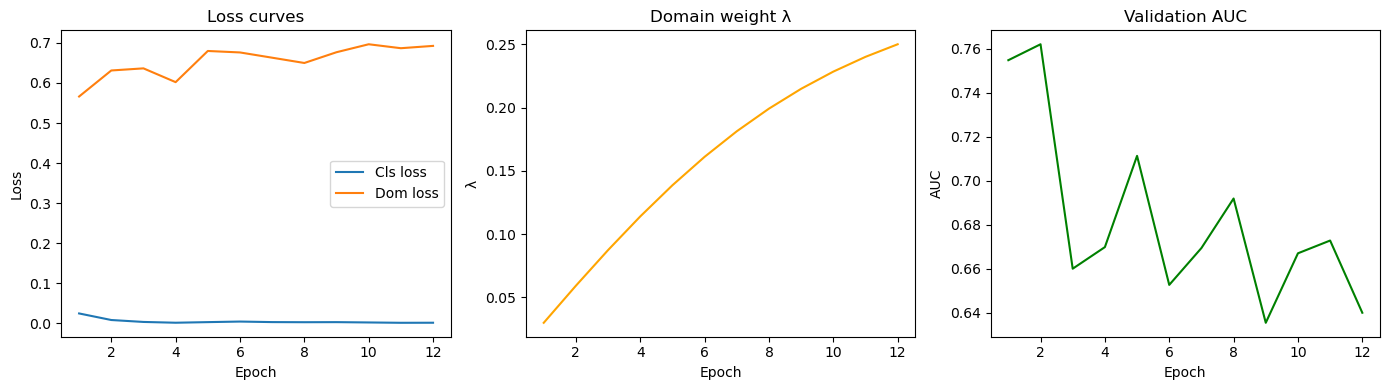

fraction=0.01 | salvato in results/runs/dann_ft_0.01/20260605_004109/figures/training_history.png


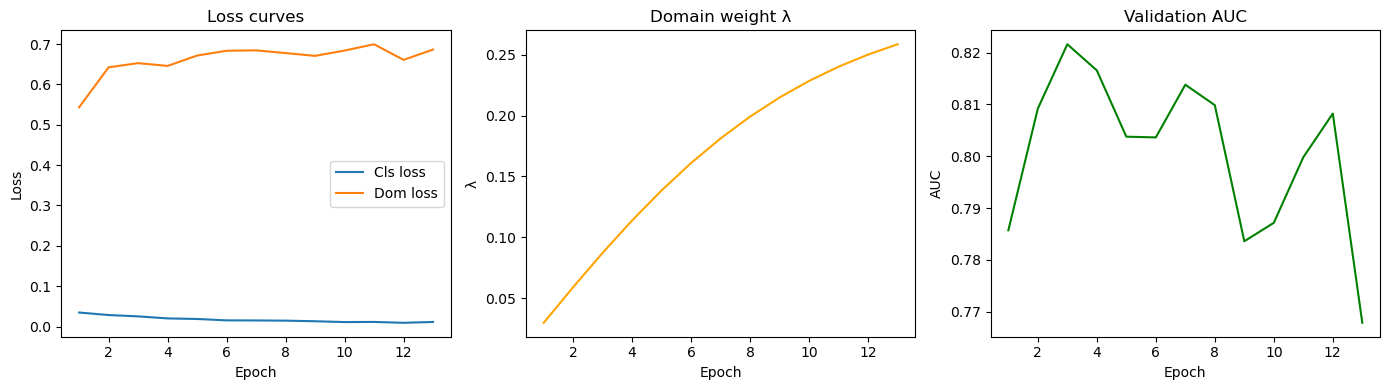

fraction=0.05 | salvato in results/runs/dann_ft_0.05/20260605_005838/figures/training_history.png


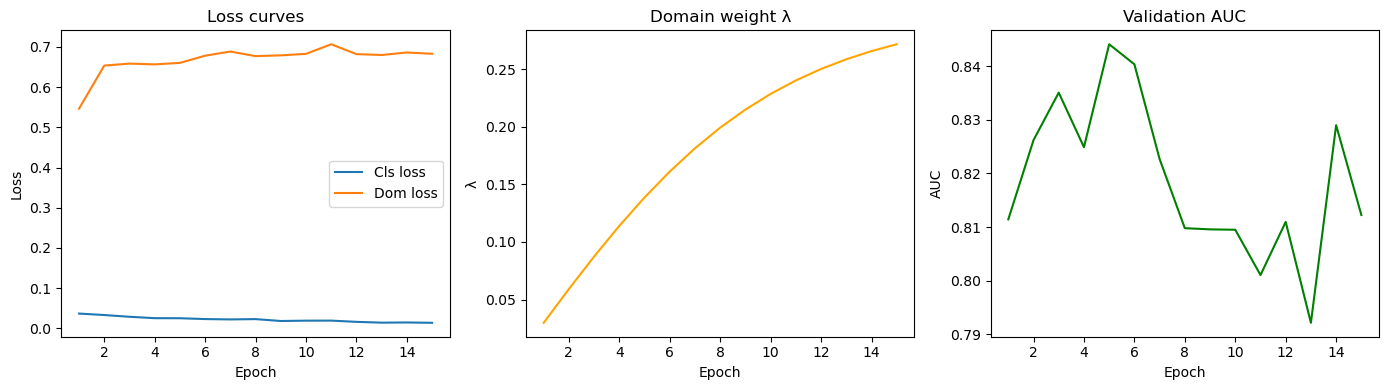

fraction=0.10 | salvato in results/runs/dann_ft_0.10/20260605_011914/figures/training_history.png


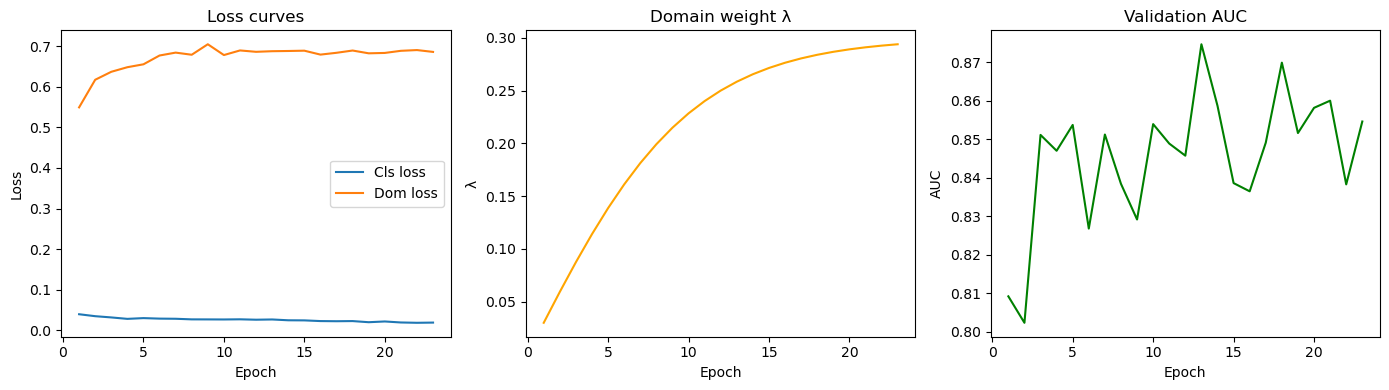

fraction=0.25 | salvato in results/runs/dann_ft_0.25/20260605_014538/figures/training_history.png


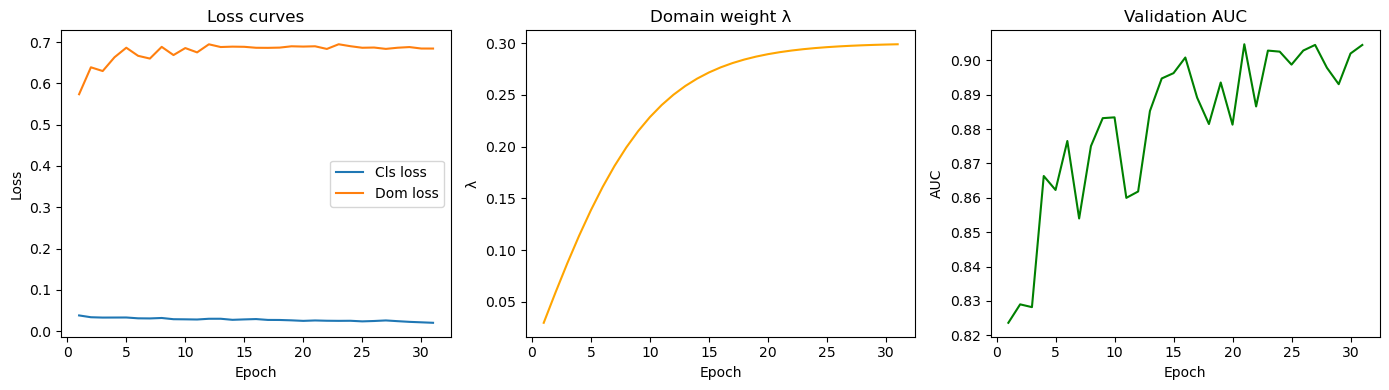

fraction=0.50 | salvato in results/runs/dann_ft_0.50/20260605_023146/figures/training_history.png


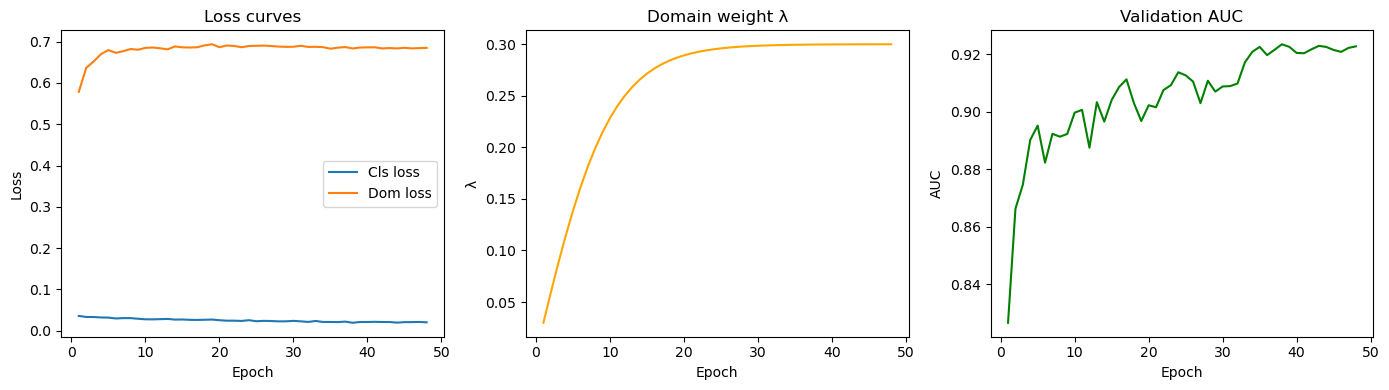

fraction=1.00 | salvato in results/runs/dann_ft_1.00/20260605_035302/figures/training_history.png


In [9]:
# 7a — Training history per ogni run DANN
for fraction in ALL_FRACTIONS:
    exp_name = f'dann_ft_{fraction:.2f}'
    rd = get_latest_run(exp_name)
    if rd is None:
        print(f'[SKIP] {exp_name}: run non trovato')
        continue
    # Custom plot for DANN: cls_loss + dom_loss + lambda
    metrics_file = rd / 'metrics.jsonl'
    if not metrics_file.exists():
        continue
    records = [json.loads(l) for l in metrics_file.read_text().strip().split('\n') if l.strip()]
    if not records:
        continue
    df_m = pd.DataFrame(records)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Loss plot
    if 'train_cls_loss' in df_m and 'train_dom_loss' in df_m:
        axes[0].plot(df_m['epoch'], df_m['train_cls_loss'], label='Cls loss')
        axes[0].plot(df_m['epoch'], df_m['train_dom_loss'], label='Dom loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].set_title('Loss curves')

    # Lambda schedule
    if 'lambda' in df_m:
        axes[1].plot(df_m['epoch'], df_m['lambda'], label='λ', color='orange')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('λ')
        axes[1].set_title('Domain weight λ')

    # AUC plot
    if 'val_auc' in df_m:
        axes[2].plot(df_m['epoch'], df_m['val_auc'], label='Val AUC', color='green')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('AUC')
        axes[2].set_title('Validation AUC')

    fig.tight_layout()
    save_path = str(rd / 'figures/training_history.png')
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'fraction={fraction:.2f} | salvato in {save_path}')

In [10]:
# 7b — Metriche riassuntive per run
print(f"{'Fraction':>10} | {'Epochs':>7} | {'Best val_auc':>13} | {'Final cls_loss':>16} | {'Final dom_loss':>16} | {'Max λ':>7}")
print('-' * 75)

for fraction in ALL_FRACTIONS:
    rd = get_latest_run(f'dann_ft_{fraction:.2f}')
    if rd is None or not (rd / 'metrics.jsonl').exists():
        continue
    lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
    entries = [json.loads(l) for l in lines if l.strip()]
    if not entries:
        continue
    n_epochs = len(entries)
    best_val = max(e.get('val_auc', 0) for e in entries)
    last = entries[-1]
    cls_loss = last.get('train_cls_loss', float('nan'))
    dom_loss = last.get('train_dom_loss', float('nan'))
    max_lambda = max(e.get('lambda', 0) for e in entries)
    print(f'{fraction*100:>9.0f}% | {n_epochs:>7} | {best_val:>13.4f} | {cls_loss:>16.6f} | {dom_loss:>16.6f} | {max_lambda:>7.4f}')

  Fraction |  Epochs |  Best val_auc |   Final cls_loss |   Final dom_loss |   Max λ
---------------------------------------------------------------------------
        1% |      12 |        0.7620 |         0.001907 |         0.692427 |  0.2501
        5% |      13 |        0.8216 |         0.011388 |         0.686367 |  0.2585
       10% |      15 |        0.8441 |         0.014031 |         0.682898 |  0.2715
       25% |      23 |        0.8747 |         0.019346 |         0.685532 |  0.2940
       50% |      31 |        0.9047 |         0.020387 |         0.684278 |  0.2988
      100% |      48 |        0.9234 |         0.020289 |         0.685017 |  0.3000


In [11]:
# 7c — val_auc massimo per run (baseline vs pseudo vs MT vs DANN)
print(f"{'Fraction':>10} | {'Base val_auc':>14} | {'Pseudo val_auc':>16} | {'MT val_auc':>13} | {'DANN val_auc':>15}")
print('-' * 75)

for f in ALL_FRACTIONS:
    def _max_val_auc(exp_name):
        rd = get_latest_run(exp_name)
        if rd is None or not (rd / 'metrics.jsonl').exists():
            return None
        lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
        aucs = [json.loads(l).get('val_auc') for l in lines if l.strip()]
        aucs = [a for a in aucs if a is not None]
        return round(max(aucs), 4) if aucs else None

    if f < 1.0:
        b_val = _max_val_auc(f'baseline_resnet18_{f:.2f}')
    else:
        b_val = _max_val_auc('baseline_resnet18_full')
    p_val = _max_val_auc(f'pseudo_label_ft_{f:.2f}')
    m_val = _max_val_auc(f'mean_teacher_ft_{f:.2f}')
    d_val = _max_val_auc(f'dann_ft_{f:.2f}')

    b_str = f'{b_val:.4f}' if b_val else 'N/A'
    p_str = f'{p_val:.4f}' if p_val else 'N/A'
    m_str = f'{m_val:.4f}' if m_val else 'N/A'
    d_str = f'{d_val:.4f}' if d_val else 'N/A'
    print(f"{f*100:>9.0f}% | {b_str:>14} | {p_str:>16} | {m_str:>13} | {d_str:>15}")

  Fraction |   Base val_auc |   Pseudo val_auc |    MT val_auc |    DANN val_auc
---------------------------------------------------------------------------
        1% |         0.7799 |              N/A |        0.6877 |          0.7620
        5% |         0.8355 |              N/A |        0.8343 |          0.8216
       10% |         0.8709 |           0.8643 |        0.8703 |          0.8441
       25% |         0.8808 |           0.8781 |        0.8747 |          0.8747
       50% |         0.9137 |           0.9174 |        0.8995 |          0.9047
      100% |         0.9279 |           0.9433 |        0.9071 |          0.9234
